In [ ]:
# Seaborn is a Python library for creating attractive data visualizations easily.
# It is built on top of Matplotlib and works well with Pandas DataFrames.

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# We will use Seaborn’s built-in datasets for easy practice.

In [ ]:
# Seaborn has several small example datasets like "tips", "iris", "penguins", etc.
# Here we load the "tips" dataset which contains information about restaurant bills.

tips = sns.load_dataset("tips")

# Display first few rows to understand the data
tips.head()

# Columns:
# total_bill – total amount of the bill
# tip – tip given by customer
# sex – gender of server
# smoker – whether the customer was a smoker
# day – day of the week
# time – Lunch or Dinner
# size – number of people in the group

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


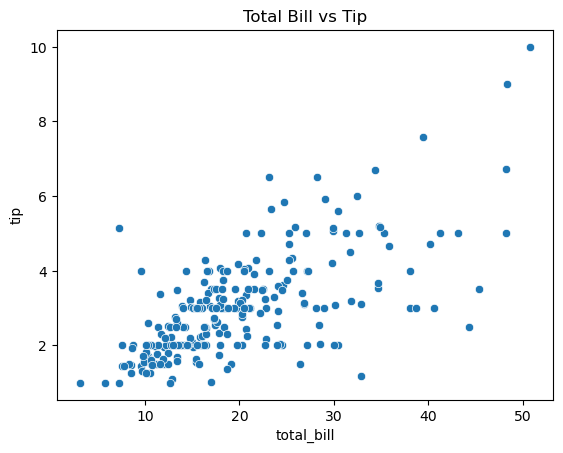

In [ ]:
# A scatter plot shows the relationship between two numeric variables.
# Arguments:
#   x – column for x-axis
#   y – column for y-axis
#   data – the DataFrame that contains those columns

sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.title("Total Bill vs Tip")
plt.show()

# Insight:
# You can see that as total_bill increases, the tip also tends to increase.

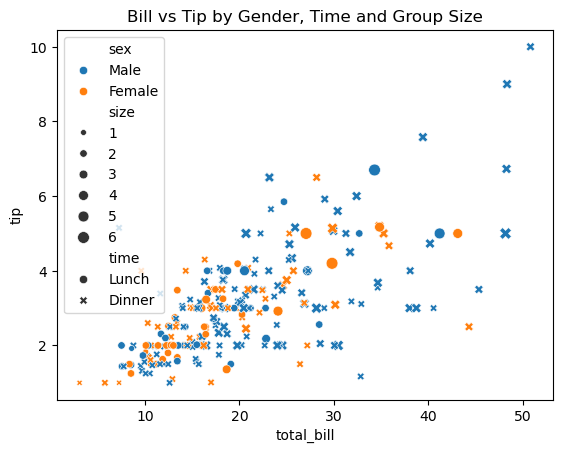

In [ ]:
# We can add more meaning using extra arguments:
#   hue   – adds color by a categorical column (here, 'sex')
#   style – changes marker shape by category (here, 'time')
#   size  – changes point size (here, 'size' = number of people)

sns.scatterplot(
    x="total_bill",
    y="tip",
    hue="sex",
    style="time",
    size="size",
    data=tips
)
plt.title("Bill vs Tip by Gender, Time and Group Size")
plt.show()

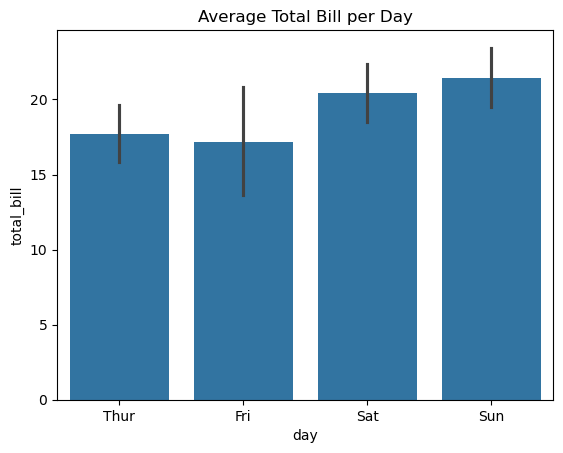

In [ ]:
# A bar plot shows the average value of one variable for each category of another.
#   x – category
#   y – numeric variable
# By default, Seaborn shows the mean with 95% confidence intervals.

sns.barplot(x="day", y="total_bill", data=tips)
plt.title("Average Total Bill per Day")
plt.show()

# Insight:
# Saturday and Sunday have higher average bills (probably weekend rush).

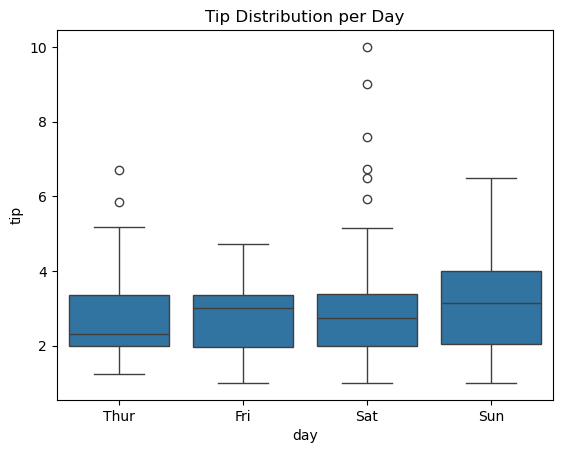

In [ ]:
# Box plots show distribution, median, and outliers.
#   x – category
#   y – numeric variable
# Each box shows how data spreads for each category.

sns.boxplot(x="day", y="tip", data=tips)
plt.title("Tip Distribution per Day")
plt.show()

# Insight:
# Saturday has more variation in tips compared to other days.

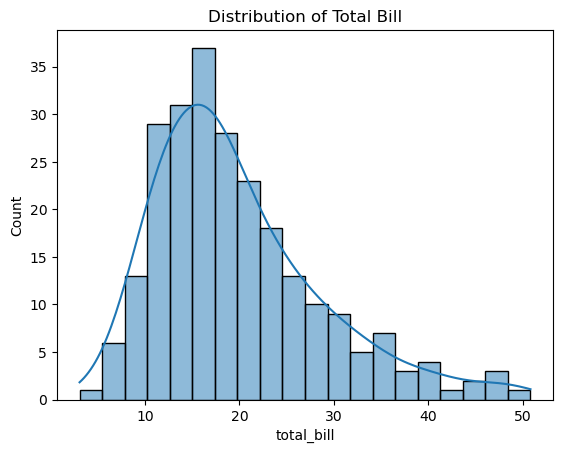

In [ ]:
# histplot shows how data is distributed (frequency of values).
# Arguments:
#   data – array or column
#   bins – number of bars
#   kde  – adds a smooth curve on top (Kernel Density Estimate)

sns.histplot(tips["total_bill"], bins=20, kde=True)
plt.title("Distribution of Total Bill")
plt.show()

# Insight:
# Most total bills are between $10 and $25.

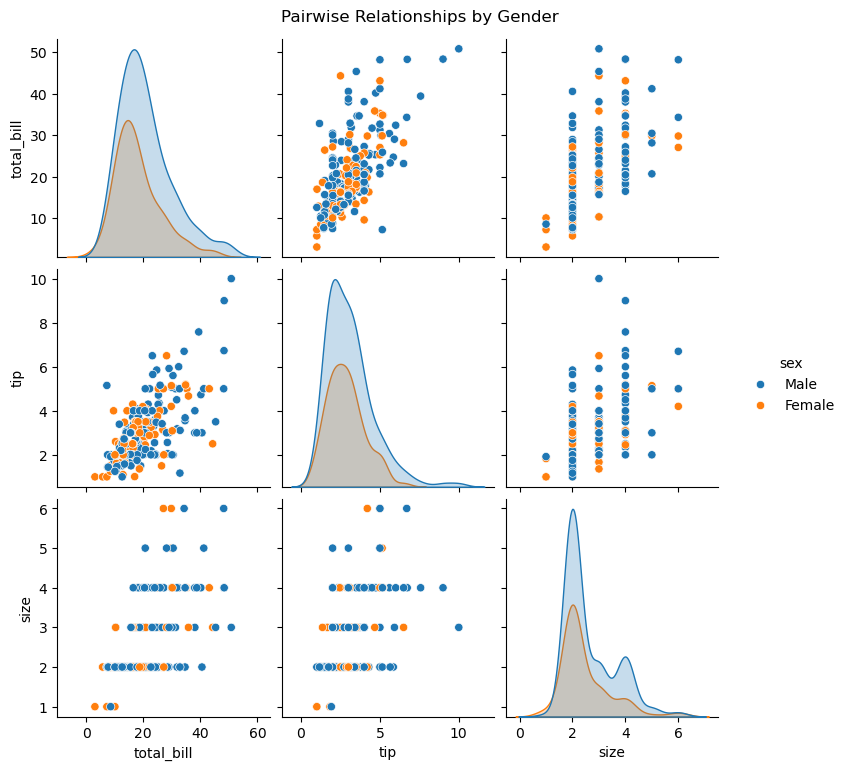

In [ ]:
# Pair plot shows relationships between all numeric variables at once.
#   hue – color by a categorical column

sns.pairplot(tips, hue="sex")
plt.suptitle("Pairwise Relationships by Gender", y=1.02)
plt.show()

# Insight:
# Quick overview of how different variables relate to each other.

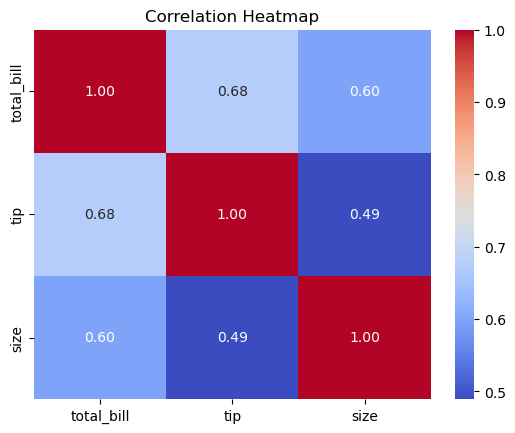

In [ ]:
# Heatmap shows correlation between numeric columns.
# Steps:
#   1. Compute correlation matrix using DataFrame.corr()
#   2. Pass it to sns.heatmap()
# Arguments:
#   annot=True – displays correlation numbers
#   fmt – number format ('.2f' = two decimals)
#   cmap – color theme

corr = tips.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Insight:
# total_bill and tip have strong positive correlation.

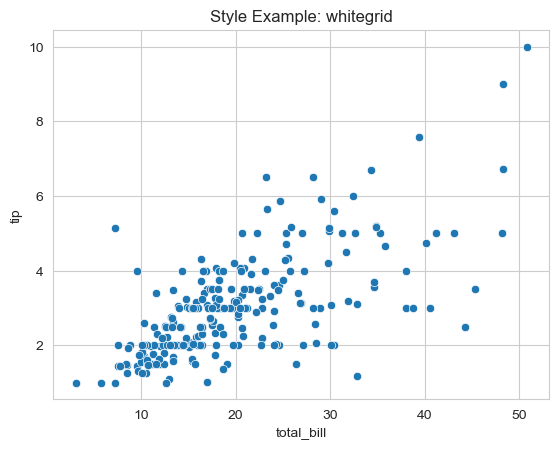

In [ ]:
# Seaborn lets you easily change the visual theme of plots.
# Options: "darkgrid", "whitegrid", "dark", "white", "ticks"

sns.set_style("whitegrid")

sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.title("Style Example: whitegrid")
plt.show()

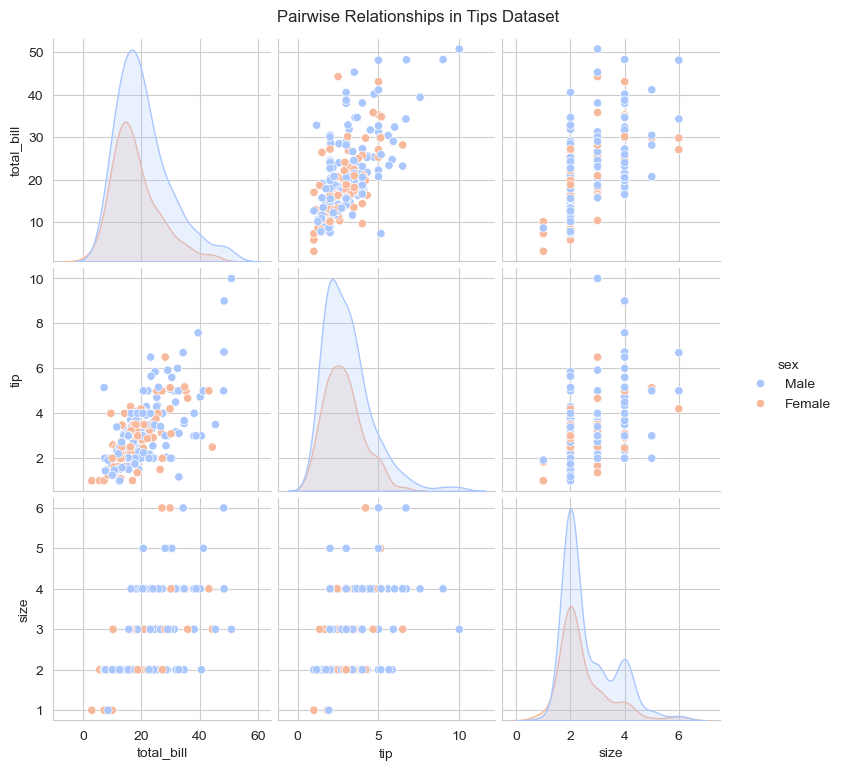

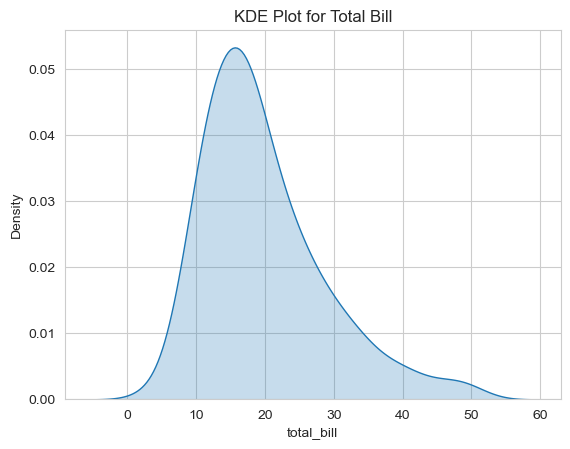

In [ ]:
# ==============================================
# Seaborn Pair Plot (sns.pairplot) — Full Explanation
# ==============================================
# The pairplot() function in Seaborn creates multiple scatter plots to show
# relationships between *all numeric columns* in a dataset.
#
# It also shows distributions (histograms or smooth KDE curves)
# for each variable along the diagonal.

import seaborn as sns
import matplotlib.pyplot as plt

# Load the example dataset
tips = sns.load_dataset("tips")

# Create pairplot
sns.pairplot(tips, hue="sex", diag_kind="kde", palette="coolwarm")
plt.suptitle("Pairwise Relationships in Tips Dataset", y=1.02)
plt.show()

# ==============================================
# Understanding the Components
# ==============================================
# ▶ Each cell (off-diagonal) shows a scatter plot comparing two numeric variables.
#   Example: One cell compares total_bill (x-axis) vs tip (y-axis)
#
# ▶ The diagonal cells show the distribution of each single variable.
#   Here we used diag_kind="kde" which plots a KDE curve instead of a histogram.

# ==============================================
# What is KDE (Kernel Density Estimate)?
# ==============================================
# KDE = a smooth version of a histogram.
# Instead of showing data in discrete bars (like histplot),
# it draws a continuous smooth curve that estimates the *probability density* of the data.
#
# Why it's useful:
#   - It helps visualize where data points are concentrated.
#   - The peaks represent where most data values lie.
#   - It makes it easier to compare multiple distributions.

# Example of KDE separately:
sns.kdeplot(data=tips, x="total_bill", fill=True)
plt.title("KDE Plot for Total Bill")
plt.show()

# ==============================================
# Important Arguments of pairplot()
# ==============================================
# data        → DataFrame you are plotting
# hue         → Adds color by a category (e.g., 'sex', 'day')
# kind        → Type of relationship plot ('scatter', 'reg', 'kde')
# diag_kind   → Type of plot on diagonal ('hist', 'kde')
# palette     → Color palette for hue (e.g., 'coolwarm', 'Set2')
# markers     → Marker shapes for hue levels
#
# Example:
# sns.pairplot(tips, hue="sex", kind="reg", diag_kind="kde", palette="Set2")

# ==============================================
# How to Read the Pair Plot
# ==============================================
# 1️Look at the diagonal first:
#     → It shows the distribution (KDE curves) of each numeric variable.
#
# 2️Then look at off-diagonal scatter plots:
#     → These show how two variables relate (positive, negative, or no correlation).
#
# 3️hue="sex":
#     → Colors each point by the gender of the customer.
#
# ==============================================
# Summary
# ==============================================
# • sns.pairplot() gives a quick overview of all numeric relationships.
# • diag_kind="kde" adds smooth curves to show distributions.
# • Use hue to highlight differences between categories.
# • Best used for small to medium datasets (4–8 numeric columns).

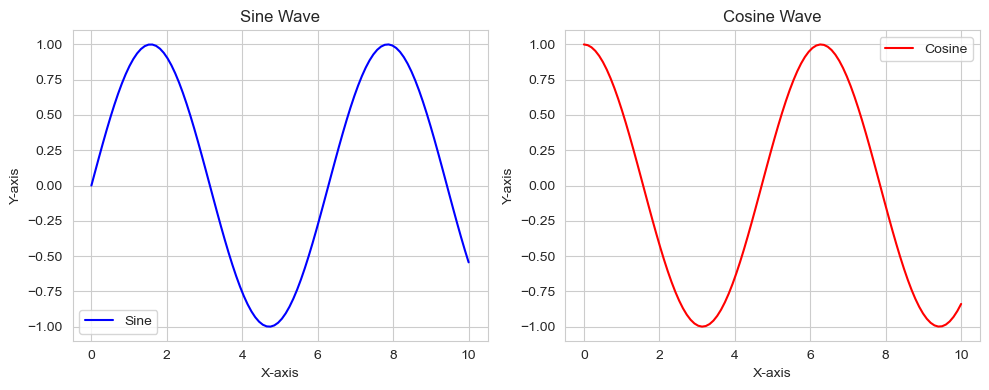

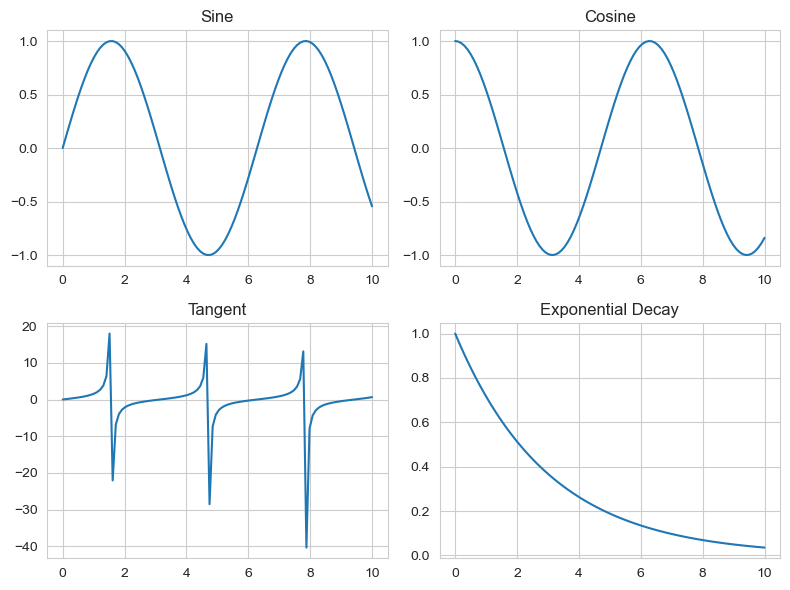

In [ ]:
# ==============================================
# Understanding Subplots in Matplotlib
# ==============================================
# Subplots are used when you want to show *multiple plots* (charts)
# in one single figure (window).
#
# Matplotlib gives a function called plt.subplots() that helps you do this easily.
# It returns TWO important things:
#   1️fig  → the overall figure (the entire window)
#   2️ ax   → the individual "axes" (each small plot area)

import matplotlib.pyplot as plt
import numpy as np

# Create some random data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# ==============================================
# Step 1: Create Subplots
# ==============================================
# plt.subplots(rows, columns)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# This means:
#  - 1 row and 2 columns → total of 2 plots side by side
#  - figsize sets the total size of the figure in inches (width, height)

# ==============================================
# Step 2: Draw on Each Subplot
# ==============================================
# ax is an array of axes objects (because we made 2 plots)
# We can access them as ax[0], ax[1], etc.

# Plot 1 – Sine curve
ax[0].plot(x, y1, color='blue', label='Sine')
ax[0].set_title("Sine Wave")           # title for first plot
ax[0].set_xlabel("X-axis")             # x label
ax[0].set_ylabel("Y-axis")             # y label
ax[0].legend()                         # show legend
ax[0].grid(True)                       # add grid lines

# Plot 2 – Cosine curve
ax[1].plot(x, y2, color='red', label='Cosine')
ax[1].set_title("Cosine Wave")
ax[1].set_xlabel("X-axis")
ax[1].set_ylabel("Y-axis")
ax[1].legend()
ax[1].grid(True)

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

# ==============================================
# What Happened Here?
# ==============================================
# fig, ax = plt.subplots(1, 2)
# → Creates 1 row and 2 columns of plots
#
# ax[0] → refers to the first subplot
# ax[1] → refers to the second subplot
#
# You can then call plot(), set_title(), etc. on each.

# ==============================================
# Common Arguments of plt.subplots()
# ==============================================
# plt.subplots(nrows, ncols, figsize=(w, h))
# nrows → number of rows
# ncols → number of columns
# figsize → size of the entire figure
#
# Example: fig, ax = plt.subplots(2, 2, figsize=(8, 6))
# → Creates 4 subplots (2 rows × 2 columns)

# ==============================================
# Bonus Example: Loop Through Subplots
# ==============================================
# You can also fill subplots using a loop:

fig, ax = plt.subplots(2, 2, figsize=(8, 6))
data = [np.sin(x), np.cos(x), np.tan(x), np.exp(-x/3)]
titles = ['Sine', 'Cosine', 'Tangent', 'Exponential Decay']

for i, axes in enumerate(ax.flat):    # ax.flat gives all subplots in one sequence
    axes.plot(x, data[i])
    axes.set_title(titles[i])
    axes.grid(True)

plt.tight_layout()
plt.show()

# ==============================================
# Summary
# ==============================================
# • plt.subplots() helps arrange multiple plots easily.
# • You get a "figure" (fig) and one or many "axes" (ax).
# • Access each subplot using ax[row][col] or ax[index].
# • Use tight_layout() to fix overlapping labels.
# • Perfect for comparing multiple variables or distributions side by side.

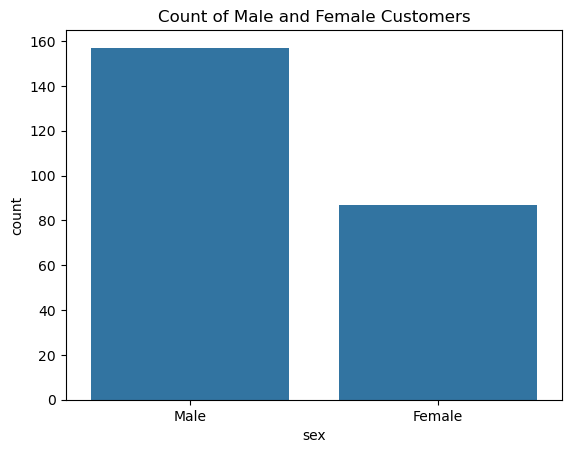

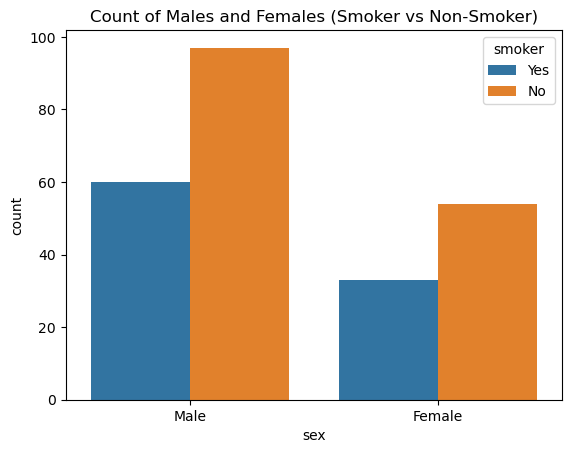

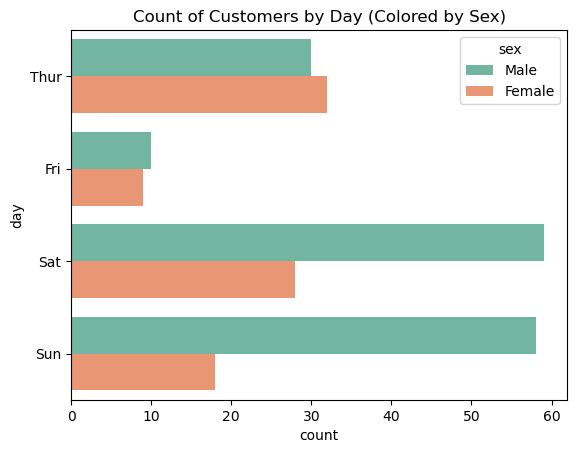

In [ ]:
# ==============================================
# Seaborn Countplot — Introduction
# ==============================================
# A countplot simply shows *how many times each category appears* in your data.
# It’s like a bar chart, but made directly from categorical (non-numeric) data.
#
# Example: In the 'tips' dataset, we can count how many customers were male or female.

import seaborn as sns
import matplotlib.pyplot as plt

# Load sample dataset
tips = sns.load_dataset("tips")

# ==============================================
# Step 1: Basic Countplot
# ==============================================
sns.countplot(data=tips, x="sex")
plt.title("Count of Male and Female Customers")
plt.show()

# ==============================================
# Explanation
# ==============================================
# sns.countplot() automatically counts the number of occurrences of each category.
# In this case:
#   - "sex" column has two categories → "Male" and "Female"
#   - It shows how many times each appears in the dataset.

# ==============================================
# Step 2: Add Hue (Split by Another Category)
# ==============================================
sns.countplot(data=tips, x="sex", hue="smoker")
plt.title("Count of Males and Females (Smoker vs Non-Smoker)")
plt.show()

# Explanation:
# hue → splits each bar by another category (different colors)
# e.g., "smoker" shows how many Males and Females were smokers or not.

# ==============================================
# Step 3: Change Orientation (Vertical ↔ Horizontal)
# ==============================================
sns.countplot(data=tips, y="day", hue="sex", palette="Set2")
plt.title("Count of Customers by Day (Colored by Sex)")
plt.show()

# Explanation:
# - Using y= instead of x= makes a *horizontal bar chart*.
# - palette changes the color theme.

# ==============================================
# Important Arguments of sns.countplot()
# ==============================================
# data   → The DataFrame containing your data
# x / y  → The column you want to count (categorical variable)
# hue    → Adds another category for color grouping
# palette → Changes color scheme (e.g. "coolwarm", "Set2", "pastel")
# order  → Manually set the order of categories
#
# Example: sns.countplot(data=tips, x="day", order=["Thur", "Fri", "Sat", "Sun"])

# ==============================================
# Summary
# ==============================================
# sns.countplot() → quick, simple visualization for categorical data
# hue → for grouping
# y= → horizontal version
# palette → customize colors
#
# Use countplot to understand:
# - Which category is most frequent
# - How two categories compare in frequency
# - Distribution of categorical values in your dataset